# Problem 4 - French-to-English Transformer


## Colab Setup
This setup cell installs helper packages, imports PyTorch/NLTK, fixes seeds, and automatically uses GPU when available.


In [1]:
import importlib, subprocess, sys

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for import_name, pip_name in [
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"),
    ("nltk", "nltk"),
]:
    ensure_package(import_name, pip_name)

import json, math, os, random, re, time, urllib.request
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm

SEED = 4106
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda


## Dataset and Homework 3 Split
The `vast_english_french.txt` content and exact Homework 3 split indices are embedded as a fallback. The notebook also writes them to `data/` so CSV outputs are reproducible.


In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DATA_TEXT = "I am cold\tJ'ai froid\nYou are tired\tTu es fatigué\nHe is hungry\tIl a faim\nShe is happy\tElle est heureuse\nWe are friends\tNous sommes amis\nThey are students\tIls sont étudiants\nThe cat is sleeping\tLe chat dort\nThe sun is shining\tLe soleil brille\nWe love music\tNous aimons la musique\nShe speaks French fluently\tElle parle français couramment\nHe enjoys reading books\tIl aime lire des livres\nThey play soccer every weekend\tIls jouent au football chaque week-end\nThe movie starts at 7 PM\tLe film commence à 19 heures\nShe wears a red dress\tElle porte une robe rouge\nWe cook dinner together\tNous cuisinons le dîner ensemble\nHe drives a blue car\tIl conduit une voiture bleue\nThey visit museums often\tIls visitent souvent des musées\nThe restaurant serves delicious food\tLe restaurant sert une délicieuse cuisine\nShe studies mathematics at university\tElle étudie les mathématiques à l'université\nWe watch movies on Fridays\tNous regardons des films le vendredi\nHe listens to music while jogging\tIl écoute de la musique en faisant du jogging\nThey travel around the world\tIls voyagent autour du monde\nThe book is on the table\tLe livre est sur la table\nShe dances gracefully\tElle danse avec grâce\nWe celebrate birthdays with cake\tNous célébrons les anniversaires avec un gâteau\nHe works hard every day\tIl travaille dur tous les jours\nThey speak different languages\tIls parlent différentes langues\nThe flowers bloom in spring\tLes fleurs fleurissent au printemps\nShe writes poetry in her free time\tElle écrit de la poésie pendant son temps libre\nWe learn something new every day\tNous apprenons quelque chose de nouveau chaque jour\nThe dog barks loudly\tLe chien aboie bruyamment\nHe sings beautifully\tIl chante magnifiquement\nThey swim in the pool\tIls nagent dans la piscine\nThe birds chirp in the morning\tLes oiseaux gazouillent le matin\nShe teaches English at school\tElle enseigne l'anglais à l'école\nWe eat breakfast together\tNous prendons le petit déjeuner ensemble\nHe paints landscapes\tIl peint des paysages\nThey laugh at the joke\tIls rient de la blague\nThe clock ticks loudly\tL'horloge tic-tac bruyamment\nShe runs in the park\tElle court dans le parc\nWe travel by train\tNous voyageons en train\nHe writes a letter\tIl écrit une lettre\nThey read books at the library\tIls lisent des livres à la bibliothèque\nThe baby cries\tLe bébé pleure\nShe studies hard for exams\tElle étudie dur pour les examens\nWe plant flowers in the garden\tNous plantons des fleurs dans le jardin\nHe fixes the car\tIl répare la voiture\nThey drink coffee in the morning\tIls boivent du café le matin\nThe sun sets in the evening\tLe soleil se couche le soir\nShe dances at the party\tElle danse à la fête\nWe play music at the concert\tNous jouons de la musique au concert\nHe cooks dinner for his family\tIl cuisine le dîner pour sa famille\nThey study French grammar\tIls étudient la grammaire française\nThe rain falls gently\tLa pluie tombe doucement\nShe sings a song\tElle chante une chanson\nWe watch a movie together\tNous regardons un film ensemble\nHe sleeps deeply\tIl dort profondément\nThey travel to Paris\tIls voyagent à Paris\nThe children play in the park\tLes enfants jouent dans le parc\nShe walks along the beach\tElle se promène le long de la plage\nWe talk on the phone\tNous parlons au téléphone\nHe waits for the bus\tIl attend le bus\nThey visit the Eiffel Tower\tIls visitent la tour Eiffel\nThe stars twinkle at night\tLes étoiles scintillent la nuit\nShe dreams of flying\tElle rêve de voler\nWe work in the office\tNous travaillons au bureau\nHe studies history\tIl étudie l'histoire\nThey listen to the radio\tIls écoutent la radio\nThe wind blows gently\tLe vent souffle doucement\nShe swims in the ocean\tElle nage dans l'océan\nWe dance at the wedding\tNous dansons au mariage\nHe climbs the mountain\tIl gravit la montagne\nThey hike in the forest\tIls font de la randonnée dans la forêt\nThe cat meows loudly\tLe chat miaule bruyamment\nShe paints a picture\tElle peint un tableau\nWe build a sandcastle\tNous construisons un château de sable\nHe sings in the choir\tIl chante dans le chœur\nWhere is the station?\tOù est la gare ?\nHow are you?\tComment ça va ?\nWhat time is it?\tQuelle heure est-il ?\nMy phone is broken\tMon téléphone est cassé\nThe water is cold\tL'eau est froide\nOpen the door\tOuvrez la porte\nClose the window\tFermez la fenêtre\nI love this song\tJ'aime cette chanson\nWe live in a big house\tNous habitons dans une grande maison\nHe drinks tea every morning\tIl boit du thé tous les matins\nShe drives a fast car\tElle conduit une voiture rapide\nThey watch the night sky\tIls regardent le ciel nocturne\nThe children love chocolate\tLes enfants adorent le chocolat\nThe teacher speaks slowly\tL'enseignant parle lentement\nI want to learn Spanish\tJe veux apprendre l'espagnol\nWe are lost in the city\tNous sommes perdus dans la ville\nThe museum is closed today\tLe musée est fermé aujourd'hui\nHe bought a new bicycle\tIl a acheté une nouvelle bicyclette\nShe makes delicious cakes\tElle fait de délicieux gâteaux\nThey listen to classical music\tIls écoutent de la musique classique\nThe sky is clear tonight\tLe ciel est dégagé ce soir\nThe dog catches the ball\tLe chien attrape la balle\nWe are waiting for the train\tNous attendons le train\nHe reads the newspaper\tIl lit le journal\nShe visits her grandparents\tElle visite ses grands-parents\nThey work in a modern factory\tIls travaillent dans une usine moderne\nThe flower has a nice smell\tLa fleur a une bonne odeur\nI need some help\tJ'ai besoin d'aide\nYou speak too fast\tTu parles trop vite\nIt is raining cats and dogs\tIl pleut des cordes\nThe computer is fast\tL'ordinateur est rapide\nWe enjoy playing video games\tNous aimons jouer à des jeux vidéo\nShe lost her keys\tElle a perdu ses clés\nHe works as a software engineer\tIl travaille comme ingénieur logiciel\nThey are buying a new apartment\tIls achètent un nouvel appartement\nThe pizza tastes good\tLa pizza a bon goût\nI forgot my umbrella\tJ'ai oublié mon parapluie\nWe swim during summer\tNous nageons pendant l'été\nThe keys are on the desk\tLes clés sont sur le bureau\nHe likes to take pictures\tIl aime prendre des photos\nShe goes to the gym regularly\tElle va régulièrement à la salle de sport\nThey speak with an accent\tIls parlent avec un accent\nThe birds are building a nest\tLes oiseaux construisent un nid\nI want a cup of hot tea\tJe veux une tasse de thé chaud\nWe crossed the old bridge\tNous avons traversé le vieux pont\nThe market sells fresh vegetables\tLe marché vend des légumes frais\nHe finished his homework quickly\tIl a fini ses devoirs rapidement\nShe wears a silver necklace\tElle porte un collier en argent\nThey went to the cinema last night\tIls sont allés au cinéma hier soir\nThe train arrives on time\tLe train arrive à l'heure\nI look forward to meeting you\tJ'ai hâte de vous rencontrer\nYou have a beautiful smile\tTu as un beau sourire\nThe bread is fresh from the bakery\tLe pain est frais de la boulangerie\nWe visited the ancient ruins\tNous avons visité les ruines antiques\nHe answers all the questions\tIl répond à toutes les questions\nShe paints her room white\tElle peint sa chambre en blanc\nThey share their lunch\tIls partagent leur déjeuner\nThe coffee machine is broken\tLa machine à café est en panne\nI see a rainbow in the sky\tJe vois un arc-en-ciel dans le ciel\nWe walk in the countryside\tNous marchons à la campagne\nThe project takes a lot of time\tLe projet prend beaucoup de temps\nHe teaches biology to teenagers\tIl enseigne la biologie aux adolescents\nShe is looking for a new job\tElle cherche un nouvel emploi\nThey practice piano every afternoon\tIls pratiquent le piano tous les après-midi\nThe soup is very hot\tLa soupe est très chaude\nI am reading an interesting novel\tJe lis un roman intéressant\nWe celebrated our anniversary\tNous avons célébré notre anniversaire\nThe map is difficult to understand\tLa carte est difficile à comprendre\nHe cleans his room every Saturday\tIl nettoie sa chambre chaque samedi\nShe won a gold medal\tElle a remporté une médaille d'or\nThey often talk about politics\tIls parlent souvent de politique\nThe cat climbs the tall tree\tLe chat grimpe sur le grand arbre\nI will call you later\tJe t'appellerai plus tard\nWe need to buy some milk\tNous devons acheter du lait\nThe performance was outstanding\tLa performance était remarquable\nHe speaks three languages fluently\tIl parle couramment trois langues\nShe works from home on Thursdays\tElle travaille à domicile le jeudi\nThey live near a beautiful lake\tIls vivent près d'un beau lac\nThe window offers a nice view\tLa fenêtre offre une belle vue\nI received a package this morning\tJ'ai reçu un colis ce matin\nWe visited the famous museum\tNous avons visité le célèbre musée\nThe dynamic landscape is beautiful\tLe paysage dynamique est magnifique\nHe writes articles for a magazine\tIl écrit des articles pour un magazine\nShe cooks traditional dishes\tElle cuisine des plats traditionnels\nThey play basketball after school\tIls jouent au basket après l'école\nThe ice cream is melting\tLa glace fond\nI lost my way in the forest\tJe me suis perdu dans la forêt\nWe are planning a trip to Japan\tNous planifions un voyage au Japon\nThe doctor advised me to rest\tLe médecin m'a conseillé de me reposer\nHe plays guitar in a local band\tIl joue de la guitare dans un groupe local\nShe translates text from English to French\tElle traduit du texte de l'anglais au français\nThey feed the ducks in the pond\tIls nourrissent les canards dans l'étang\nThe mirror reflects the light\tLe miroir reflète la lumière\nI enjoy walking in the rain\tJ'aime marcher sous la pluie\nWe are going to the beach tomorrow\tNous allons à la plage demain\nThe library has thousands of books\tLa bibliothèque contient des milliers de livres\nHe drives a red motorcycle\tIl conduit une moto rouge\nShe loves to wear colorful hats\tElle adore porter des chapeaux colorés\nThey built a small wooden cabin\tIls ont construit une petite cabane en bois\nThe winter is very cold here\tL'hiver est très froid ici\nPlease pass me the salt\tS'il vous plaît, passez-moi le sel\nThe child is drawing a house\tL'enfant dessine une maison\nWe are going to buy groceries\tNous allons faire des courses\nHe left his wallet at home\tIl a laissé son portefeuille à la maison\nShe speaks English with confidence\tElle parle anglais avec assurance\nThey are watching a football match\tIls regardent un match de football\nThe teacher answers the question\tL'enseignant répond à la question\nI enjoy listening to jazz music\tJ'aime écouter de la musique de jazz\nWe need a bigger table\tNous avons besoin d'une plus grande table\nThe weather is perfect today\tLe temps est parfait aujourd'hui\nHe wants to become a doctor\tIl veut devenir médecin\nShe wears a warm winter coat\tElle porte un manteau d'hiver chaud\nThey traveled to Italy last summer\tIls ont voyagé en Italie l'été dernier\nThe dog is sleeping on the rug\tLe chien dort sur le tapis\nI have an important meeting tomorrow\tJ'ai une réunion importante demain\nWe love eating fresh fruit\tNous adorons manger des fruits frais\nThe store opens early in the morning\tLe magasin ouvre tôt le matin\nHe writes stories for children\tIl écrit des histoires pour enfants\nShe works at a software company\tElle travaille dans une entreprise de logiciels\nThey are building a new school\tIls construisent une nouvelle école\nThe soup tastes delicious\tLa soupe est délicieuse\nI need to charge my phone\tJe dois charger mon téléphone\nWe went for a walk in the woods\tNous sommes allés nous promener dans les bois\nThe keys are missing\tLes clés ont disparu\nHe likes to play chess\tIl aime jouer aux échecs\nShe practices yoga every morning\tElle pratique le yoga tous les matins\nThey speak French at home\tIls parlent français à la maison\nThe birds sing in the trees\tLes oiseaux chantent dans les arbres\nI want to drink a glass of milk\tJe veux boire un verre de lait\nWe crossed the river by boat\tNous avons traversé la rivière en bateau\nThe restaurant is very busy tonight\tLe restaurant est très fréquenté ce soir\nHe finished his book yesterday\tIl a fini son livre hier\nShe wears a beautiful gold ring\tElle porte une belle bague en or\nThey go to the beach every summer\tIls vont à la plage chaque été\nThe train leaves at noon\tLe train part à midi\nI look forward to the weekend\tJ'attends le week-end avec impatience\nYou have a very nice house\tVous avez une très belle maison\nThe bread is hot\tLe pain est chaud\nWe visited the ancient castle\tNous avons visité le château antique\nHe answers the phone quickly\tIl répond rapidement au téléphone\nShe paints her nails red\tElle se peint les ongles en rouge\nThey share their secrets\tIls partagent leurs secrets\nThe coffee is too hot to drink\tLe café est trop chaud pour être bu\nI see a plane in the sky\tJe vois un avion dans le ciel\nWe walk to school together\tNous allons à l'école ensemble\nThe project requires a lot of effort\tLe projet demande beaucoup d'efforts\nHe teaches mathematics to children\tIl enseigne les mathématiques aux enfants\nShe is looking for her lost dog\tElle cherche son chien perdu\nThey practice soccer every evening\tIls s'entraînent au football tous les soirs\nThe tea is very sweet\tLe thé est très sucré\nI am reading a classic novel\tJe lis un roman classique\nWe celebrated his graduation\tNous avons célébré sa remise de diplôme\nThe instructions are easy to follow\tLes instructions sont faciles à suivre\nHe cleans his bicycle on Sundays\tIl nettoie sa bicyclette le dimanche\nShe won a tennis match\tElle a gagné un match de tennis\nThey often talk about history\tIls parlent souvent d'histoire\nThe monkey climbs the banana tree\tLe simge grimpe sur le bananier\nI will visit you tomorrow\tJe te rendrai visite demain\nWe need to buy some bread\tNous devons acheter du pain\nThe concert was spectacular\tLe concert était spectaculaire\nHe speaks four languages fluently\tIl parle couramment quatre langues\nShe works part-time at the library\tElle travaille à temps partiel à la bibliothèque\nThey live in a small village\tIls vivent dans un petit village\nThe door has a secure lock\tLa porte a une serrure sécurisée\nI received a letter from my friend\tJ'ai reçu une lettre de mon ami\nWe visited the historic monument\tNous avons visité le monument historique\nThe autumn leaves are beautiful\tLes feuilles d'automne sont magnifiques\nHe writes scripts for movies\tIl écrit des scénarios pour des films\nShe cooks a delicious dinner\tElle cuisine un délicieux dîner\nThey play volleyball on the beach\tIls jouent au volley-ball sur la plage\nThe ice is melting quickly\tLa glace fond rapidement\nI lost my keys in the grass\tJ'ai perdu mes clés dans l'herbe\nWe are planning a trip to London\tNous planifions un voyage à Londres\nThe nurse advised him to sleep\tL'infirmière lui a couseeillé de dormir\nHe plays drums in a rock band\tIl joue de la batterie dans un groupe de rock\nShe translates technical documents\tElle traduit des documents techniques\nThey feed the birds in the park\tIls nourrissent les oiseaux dans le parc\nThe ocean reflects the blue sky\tL'océan reflète le ciel bleu\nI enjoy walking in the snow\tJ'aime marcher dans la neige\nWe are going to the museum tomorrow\tNous allons au musée demain\nThe library is a quiet place\tLa bibliothèque est un endroit calme\nHe drives a green truck\tIl conduit un camion vert\nShe loves to wear long skirts\tElle adore porter des jupes longues\nThey built a large brick house\tIls ont construit une grande maison en brique\nThe summer is very hot here\tL'été est très chaud ici\nTurn left at the intersection\tTournez à gauche à l'intersection\nPlease close the gate\tS'il vous plaît, fermez la barrière\nHe is looking for his glasses\tIl cherche ses lunettes\nShe bought a beautiful painting\tElle a acheté un beau tableau\nWe watched the sunrise this morning\tNous avons regardé le lever du soleil ce matin\nThey listen to the teacher attentively\tIls écoutent l'enseignant attentivement\nThe water in the lake is clear\tL'eau du lac est claire\nI want to eat an apple\tJe veux manger une pomme\nWe are ready to start the game\tNous sommes prêts à commencer le jeu\nHe forgot his password\tIl a oublié son mot de passe\nShe works in a laboratory\tElle travaille dans un laboratoire\nThey built a campfire last night\tIls ont fait un feu de camp hier soir\nThe bread smells wonderful\tLe pain sent merveilleusement bon\nI need a new pair of shoes\tJ'ai besoin d'une nouvelle paire de chaussures\nWe are going to visit our aunt\tNous allons rendre visite à notre tante\nHe likes to read science fiction\tIl aime lire de la science-fiction\nShe practices the violin every day\tElle joue du violon tous les jours\nThey speak Spanish fluently\tIls parlent espagnol couramment\nThe squirrels gather nuts for winter\tLes écureuils ramassent des noisettes pour l'hiver\nI want a hot cup of coffee\tJe veux une tasse de café chaud\nWe crossed the desert by camel\tNous avons traversé le désert à dos de chameau\nThe hotel is very comfortable\tL'hôtel est très confortable\nHe finished his test early\tIl a fini son test en avance\nShe wears a diamond necklace\tElle porte un collier de diamants\nThey go skiing every winter\tIls vont skier chaque hiver\nThe bus arrives at five o'clock\tLe bus arrive à cinq heures\nI look forward to the holidays\tJ'attends les vacances avec impatience\nYou have a beautiful garden\tVous avez un magnifique jardin\nThe milk is cold\tLe lait est froid\nWe visited the ancient pyramid\tNous avons visité la pyramide antique\nHe answers the email immediately\tIl répond immédiatement à l'e-mail\nShe paints her bedroom blue\tElle peint sa chambre en bleu\nThey share their toys\tIls partagent leurs jouets\nThe tea is too sweet to drink\tLe thé est trop sucré pour être bu\nI see a ship in the distance\tJe vois un navire au loin\nWe walk through the park together\tNous marchons dans le parc ensemble\nThe assignment requires research\tLe devoir nécessite des recherches\nHe teaches chemistry to university students\tIl enseigne la chimie aux étudiants universitaires\nShe is looking for her cat\tElle cherche son chat\nThey practice running every morning\tIls s'entraînent à la course tous les matins\nThe coffee is very strong\tLe café est très fort\nI am reading a modern novel\tJe lis un roman moderne\nWe celebrated their wedding\tNous avons célébré leur mariage\nThe guide is easy to read\tLe guide est facile à lire\nHe cleans his desk every evening\tIl nettoie son bureau chaque soir\nShe won a chess tournament\tElle a gagné un tournoi d'échecs\nThey often talk about fashion\tIls parlent souvent de mode\nThe koala climbs the eucalyptus tree\tLe koala grimpe sur l'eucalyptus\nI will fix it tomorrow\tJe le réparerai demain\nWe need to buy some eggs\tNous devons acheter des œufs\nThe match was intense\tLe match était intense\nHe speaks five languages fluently\tIl parle couramment cinq langues\nShe works full-time at the hospital\tElle travaille à plein temps à l'hôpital\nThey live in a large city\tIls vivent dans une grande ville\nThe door has a wooden handle\tLa porte a une poignée en bois\nI received an invitation to the party\tJ'ai reçu une invitation à la fête\nWe visited the national park\tNous avons visité le parc national\nThe spring flowers are blooming\tLes fleurs du printemps épanouissent\nHe writes articles for a website\tIl écrit des articles pour un site web\nShe cooks a traditional meal\tElle cuisine un repas traditionnel\nThey play tennis on the weekends\tIls jouent au tennis le week-end\nThe snow is melting fast\tLa neige fond rapidement\nI lost my ring in the ocean\tJ'ai perdu ma bague dans l'océan\nWe are planning a trip to Rome\tNous planifions un voyage à Rome\nThe dentist advised me to brush\tLe dentiste m'a conseillé de me brosser les dents\nHe plays bass in a jazz band\tIl joue de la basse dans un groupe de jazz\nShe translates legal agreements\tElle traduit des contrats juridiques\nThey feed the pigeons in the square\tIls nourrissent les pigeons sur la place\nThe window reflects the garden\tLa fenêtre reflète le jardin\nI enjoy walking in the forest\tJ'aime marcher dans la forêt\nWe are going to the concert tomorrow\tNous allons au concert demain\nThe museum is an educational place\tLe musée est un lieu éducatif\nHe drives a black sedan\tIl conduit une berline noire\nShe loves to wear modern jackets\tElle adore porter des vestes modernes\nThey built a concrete wall\tIls ont construit un mur en béton\nThe autumn is very rainy here\tL'automne est très pluvieux ici\nThe keys are missing from my coat pocket\tLes clés manquent dans la poche de mon manteau\nI will send you the confirmation email shortly\tJe vous enverrai l'e-mail de confirmation sous peu\nWe discovered a quiet path through the mountains\tNous avons découvert un sentier tranquille à travers les montagnes\nThe chef prepared a special menu for the guests\tLe chef a préparé un menu spécial pour les invités\nShe enjoys listening to classical music at night\tElle aime écouter de la musique classique la nuit\nThey bought a house with a huge backyard\tIls ont acheté une maison avec un immense jardin\nThe local library is closed on bank holidays\tLa bibliothèque locale est fermée les jours fériés\nHe lost his balance and fell off the bicycle\tIl a perdu l'équilibre et est tombé de sa bicyclette\nWe need to complete this layout task by midnight\tNous devons terminer cette tâche de mise en page avant minuit\nThe flight was delayed due to heavy fog\tLe vol a été retardé en raison d'un brouillard épais\nShe teaches chemistry at a prestigious college\tElle enseigne la chimie dans un collège prestigieux\nThey spent their vacation exploring small islands\tIls ont passé leurs vacances à explorer de petites îles\nThe old wooden bridge is safe to cross\tLe vieux pont en bois est sûr à traverser\nI cannot find my passport anywhere in the room\tJe ne trouve mon passeport nulle part dans la chambre\nWe always have a big dinner on Christmas Eve\tNous dînons toujours copieusement le soir du réveillon de Noël\nThe engine makes a strange noise when starting\tLe moteur fait un bruit étrange au démarrage\nHe decided to paint his front door bright green\tIl a décidé de peindre sa porte d'entrée en vert vif\nShe always drinks warm milk before going to bed\tElle boit toujours du lait chaud avant de se coucher\nThey are planning to build a modern art gallery\tIls prévoient de construire une galerie d'art moderne\nThe weather forecast predicts heavy snow tomorrow\tLes prévisions météo annoncent de fortes chutes de neige demain\nI bought a new pair of leather boots today\tJ'ai acheté une nouvelle paire de bottes en cuir aujourd'hui\nWe walked around the lake during the sunset\tNous avons marché autour du lac pendant le coucher du soleil\nThe new software update fixed several critical bugs\tLa nouvelle mise à jour logicielle a corrigé plusieurs bugs critiques\nHe runs five miles every morning before breakfast\tIl court cinq milles tous les matins avant le petit déjeuner\nShe wrote a deeply touching letter to her family\tElle a écrit une lettre profondément touchante à sa famille\nThey regular meet up to discuss global politics\tIls se réunissent régulièrement pour discuter de politique mondiale\nThe flower shop on the corner sells fresh roses\tLe fleuriste du coin vend des roses fraîches\nI accidentally left my umbrella inside the taxi\tJ'ai accidentellement laissé mon parapluie dans le taxi\nWe absolute love spending our summers in France\tNous adorons absolument passer nos étés en France\nThe computer screen is covered in fingerprints\tL'écran de l'ordinateur est couvert d'empreintes digitales\nHe works long hours as a financial consultant\tIl travaille de longues heures comme consultant financier\nShe loves baking fresh apple pies on Sundays\tElle adore cuisiner des tartes aux pommes fraîches le dimanche\nThey live in a beautiful apartment facing the river\tIls vivent dans un bel appartement face à la rivière\nThe soup needs a little more salt and pepper\tLa soupe a besoin d'un peu plus de sel et de poivre\nI need to renew my driver's license next week\tJe dois renouveler mon permis de conduire la semaine prochaine\nWe crossed the crowded street near the station\tNous avons traversé la rue bondée près de la gare\nThe organic market opens at dawn on Saturdays\tLe marché biologique ouvre à l'aube le samedi\nHe finished his science project ahead of schedule\tIl a terminé son projet scientifique en avance sur le calendrier\nShe wears a beautiful silver bracelet on her wrist\tElle porte un beau bracelet en argent au poignet\nThey went to see a broadway play last month\tIls sont allés voir une pièce de théâtre à Broadway le mois dernier\nThe morning train is usually packed with commuters\tLe train du matin est généralement bondé de banlieusards\nI look forward to collaborating with your team\tJ'ai hâte de collaborer avec votre équipe\nYou have a truly wonderful collection of vinyl records\tVous avez une collection de disques vinyles vraiment magnifique\nThe bread at this bakery is always crunchy\tLe pain de cette boulangerie est toujours croustillant\nWe explored the narrow corridors of the old castle\tNous avons exploré les couloirs étroits du vieux château\nHe answered the emergency phone call within seconds\tIl a répondu à l'appel téléphonique d'urgence en quelques secondes\nShe decided to dye her hair dark brown\tElle a décidé de se teindre les cheveux en brun foncé\nThey gladly share their knowledge with the students\tIls partagent volontiers leurs connaissances avec les étudiants\nThe coffee machine requires immediate maintenance\tLa machine à café nécessite un entretien immédiat\nI saw an interesting shooting star last night\tJ'ai vu une étoile filante intéressante la nuit dernière\nWe prefer walking through the quiet botanical gardens\tNous préférons nous promener dans les jardins botaniques calmes\nThe final exam is extremely difficult to pass\tL'examen final est extrêmement difficile à réussir\nHe teaches history to middle school children\tIl enseigne l'histoire à des enfants du collège\nShe is actively looking for a room to rent\tElle cherche activement une chambre à louer\nThey practice their instruments for hours every day\tIls pratiquent leurs instruments pendant des heures chaque jour\nThe hot chocolate was served with mini marshmallows\tLe chocolat chaud était servi avec des mini guimauves\nI am currently reading a fascinating historical biography\tJe lis actuellement une biographie historique fascinante\nWe celebrated their golden wedding anniversary yesterday\tNous avons célébré leur anniversaire de mariage d'or hier\nThe map of the subway network is confusing\tLa carte du réseau de métro est déroutante\nHe vacuums his entire house every Friday afternoon\tIl passe l'aspirateur dans toute sa maison tous les vendredis après-midi\nShe won first place in the writing contest\tElle a remporté la première place au concours d'écriture\nThey often debate about economics and resource distribution\tIls débattent souvent d'économie et de distribution des ressources\nThe golden retriever jumped into the cold river\tLe golden retriever a sauté dans la rivière froide\nI will text you when I arrive home\tJe t'enverrai un SMS quand j'arriverai à la maison\nWe need to pick up a few items\tNous devons récupérer quelques articles\nThe theater performance received a standing ovation\tLa performance théâtrale a reçu une ovation debout\nHe speaks five dialects of Chinese fluently\tIl parle couramment cinq dialectes du chinois\nShe works part-time as a tourist guide\tElle travaille à temps partiel comme guide touristique\nThey moved into a cozy cottage by the sea\tIls ont emménagé dans un chalet confortable au bord de la mer\nThe main entrance has an automatic glass door\tL'entrée principale a une porte vitrée automatique\nI received a funny postcard from my cousin\tJ'ai reçu une carte postale amusante de mon cousin\nWe visited the national monument during our holiday\tNous avons visité le monument national pendant nos vacances\nThe red leaves cover the ground in October\tLes feuilles rouges couvrent le sol en octobre\nHe writes scripts for successful television series\tIl écrit des scénarios pour des séries télévisées à succès\nShe cooked a traditional Sunday roast for everyone\tElle a cuisiné un rôti du dimanche traditionnel pour tout le monde\nThey love playing beach volleyball during the summer\tIls adorent jouer au volley-ball de plage pendant l'été\nThe thick glacier is melting due to climate change\tLe glacier épais fond en raison du changement climatique\nI dropped my keys somewhere in the sandbox\tJ'ai fait tomber mes clés quelque part dans le bac à sable\nWe are planning a massive road trip across Canada\tNous planifions un grand voyage en voiture à travers le Canada\nThe emergency room nurse told him to rest\tL'infirmière des urgences lui a dit de se reposer\nHe plays acoustic guitar in a jazz club\tIl joue de la guitare acoustique dans un club de jazz\nShe translates ancient manuscripts into modern languages\tElle traduit des manuscrits anciens en langues modernes\nThey feed the hungry pigeons near the fountain\tIls nourrissent les pigeons affamés près de la fontaine\nThe crystal clear window reflects the beautiful sunset\tLa fenêtre transparente reflète le magnifique coucher de soleil\nI love walking through the park during autumn\tJ'aime me promener dans le parc pendant l'automne\nWe are going to the science museum tomorrow morning\tNous allons au musée des sciences demain matin\nThe public library is an excellent study space\tLa bibliothèque publique est un excellent espace d'étude\nHe drives an old green delivery truck\tIl conduit un vieux camion de livraison vert\nShe loves to wear long flowing cotton skirts\tElle adore porter de longues jupes amples en coton\nThey constructed a large stone wall around the property\tIls ont construit un grand mur de pierre autour de la propriété\nThe winter season is exceptionally long this year\tLa saison d'hiver est exceptionnellement longue cette année\nPlease step away from the closing doors\tS'il vous plaît, éloignez-vous des portes qui se ferment\nHe is searching everywhere for his lost wallet\tIl cherche partout son portefeuille perdu\nShe purchased a rare vintage painting at the auction\tElle a acheté un tableau vintage rare aux enchères\nWe watched the spectacular sunrise over the ocean\tNous avons regardé le lever de soleil spectaculaire sur l'océan\nThey listen to the professor with absolute attention\tIls écoutent le professeur avec une attention absolue\nThe pure water in the mountain stream is refreshing\tL'eau pure du ruisseau de montagne est rafraîchissante\nI want to eat a fresh green apple\tJe veux manger une pomme verte fraîche\nWe are entirely ready to start the tournament\tNous sommes entièrement prêts à commencer le tournoi\nHe completely forgot his secure login credentials\tIl a complètement oublié ses identifiants de connexion sécurisés\nShe works in a high-tech chemical laboratory\tElle travaille dans un laboratoire chimique de haute technologie\nThey built a safe campfire near the lake\tIls ont fait un feu de camp sûr près du lac\nThe fresh bread smells absolutely incredible\tLe pain frais sent absolument incroyable\nI urgently need a new pair of running shoes\tJ'ai un besoin urgent d'une nouvelle paire de chaussures de course\nWe are going to visit our relatives next month\tNous allons rendre visite à nos proches le mois prochain\nHe loves to read classic science fiction novels\tIl aime lire des romans classiques de science-fiction\nShe practices the cello for three hours every day\tElle pratique le violoncelle pendant trois heures chaque jour\nThey speak standard European Spanish fluently\tIls parlent couramment l'espagnol européen standard\nThe birds gather dry twigs for their nests\tLes oiseaux ramassent des brindilles sèches pour leurs nids\nI want a cold glass of iced coffee\tJe veux un verre froid de café glacé\nWe crossed the wide river using a wooden raft\tNous avons traversé la large rivière en utilisant un radeau en bois\nThe luxury hotel is incredibly clean and comfortable\tL'hôtel de luxe est incroyablement propre et confortable\nHe completed the online assessment very early\tIl a terminé l'évaluation en ligne très tôt\nShe wears an elegant diamond ring on her finger\tElle porte une élégante bague en diamant au doigt\nThey go snowboarding every single winter holiday\tIls vont faire du snowboard à chaque vacances d'hiver\nThe city bus arrives precisely at five o'clock\tLe bus de la ville arrive précisément à cinq heures\nI look forward to the upcoming summer holidays\tJ'attends avec impatience les prochaines vacances d'été\nYou have a beautiful garden full of colorful roses\tVous avez un magnifique jardin plein de roses colorées\nThe organic milk must be kept cold\tLe lait biologique doit être gardé au frais\nWe visited the historical ruins of the pyramid\tNous avons visité les ruines historiques de la pyramide\nHe replies to all customer emails immediately\tIl répond immédiatement à tous les e-mails des clients\nShe paints her small bedroom light blue\tElle peint sa petite chambre en bleu clair\nThe small children share their colorful toys\tLes petits enfants partagent leurs jouets colorés\nThe black tea is too sweet to drink comfortably\tLe thé noir est trop sucré pour être bu confortablement\nI can see a large cruise ship in the distance\tJe peux voir un grand navire de croisière au loin\nWe walk through the central park every afternoon\tNous marchons dans le parc central chaque après-midi\nThis complex university assignment requires thorough research\tCe devoir universitaire complexe nécessite des recherches approfondies\nHe teaches molecular chemistry to advanced students\tIl enseigne la chimie moléculaire à des étudiants avancés\nShe is looking everywhere for her lost cat\tElle cherche son chat perdu partout\nThey practice long-distance running every single morning\tIls s'entraînent à la course de fond tous les matins\nThe morning espresso coffee is exceptionally strong\tLe café expresso du matin est exceptionnellement fort\nI am currently reading a classic Russian novel\tJe lis actuellement un roman classique russe\nWe happily celebrated their beautiful wedding ceremony\tNous avons joyeusement célébré leur magnifique cérémonie de mariage\nThe assembly guide is very easy to read\tLe guide d'assemblage est très facile à lire\nHe cleans his office desk every single evening\tIl nettoie son bureau chaque soir\nShe won a highly competitive chess tournament\tElle a gagné un tournoi d'échecs très compétitif\nThey often talk about modern fashion trends\tIls parlent souvent des tendances de la mode moderne\nThe sleepy koala climbs the tall eucalyptus tree\tLe koala endormi grimpe sur le grand eucalyptus\nI will fix the broken window tomorrow morning\tJe réparerai la fenêtre cassée demain matin\nWe need to buy a dozen fresh eggs\tNous devons acheter une douzaine d'œufs frais\nThe championship football match was incredibly intense\tLe match de football du championnat était incroyablement intense\nHe speaks six international languages completely fluently\tIl parle couramment six langues internationales\nShe works full-time at the general hospital\tElle travaille à plein temps à l'hôpital général\nThey live in a large metropolitan city\tIls vivent dans une grande ville métropolitaine\nThe heavy door has a beautiful wooden handle\tLa lourde porte a une belle poignée en bois\nI received an official invitation to the party\tJ'ai reçu une invitation officielle à la fête\nWe spent a week visiting the national park\tNous avons passé une semaine à visiter le parc national\nThe beautiful spring flowers are finally blooming\tLes belles fleurs du printemps s'épanouissent enfin\nHe writes analytical articles for a popular website\tIl écrit des articles analytiques pour un site web populaire\nShe cooks a traditional three-course meal for dinner\tElle cuisine un repas traditionnel à trois plats pour le dîner\nThey regularly play tennis on the weekends\tIls jouent régulièrement au tennis le week-end\nThe thick snow is melting remarkably fast\tLa neige épaisse fond remarquablement vite\nI unfortunately lost my gold ring in the ocean\tJ'ai malheureusement perdu ma bague en or dans l'océan\nWe are planning a dream trip to Rome next year\tNous planifions un voyage de rêve à Rome l'année prochaine\nThe local dentist advised me to brush twice daily\tLe dentiste local m'a conseillé de me brosser les dents deux fois par jour\nHe plays bass guitar in a professional jazz band\tIl joue de la basse dans un groupe de jazz professionnel\nShe translates complex legal agreements for global companies\tElle traduit des contrats juridiques complexes pour des entreprises mondiales\nThey feed the white pigeons in the public square\tIls nourrissent les pigeons blancs sur la place publique\nThe large bedroom window reflects the green garden\tLa grande fenêtre de la chambre reflète le jardin verdoyant\nI truly enjoy walking in the dense forest\tJ'aime vraiment marcher dans la forêt dense\nWe are definitely going to the live concert tomorrow\tNous allons certainement au concert en direct demain\nThe historical museum is a highly educational place\tLe musée historique est un lieu hautement éducatif\nHe drives a black luxury sedan to work\tIl conduit une berline de luxe noire pour aller au travail\nShe loves to wear modern leather jackets\tElle adore porter des vestes en cuir modernes\nThey built a thick concrete wall for safety\tIls ont construit un épais mur en béton pour la sécurité\nThe autumn weather is very rainy here\tLe temps d'automne est très pluvieux ici\nAlways look both ways before crossing the road\tRegardez toujours des deux côtés avant de traverser la route\nPlease verify your entry details before submitting\tVeuillez vérifier vos informations de saisie avant de soumettre\nHe decided to adopt a puppy from the shelter\tIl a décidé d'adopter un chiot du refuge\nShe bought an expensive leather bag yesterday\tElle a acheté un sac en cuir cher hier\nWe watched the storm clouds gather over the hills\tNous avons regardé les nuages d'orage s'accumuler sur les collines\nThey follow the instructions carefully to avoid mistakes\tIls suivent attentivement les instructions pour éviter les erreurs\nThe water temperature in the pool is pleasant\tLa température de l'eau dans la piscine est agréable\nI want to drink a hot cup of tea\tJe veux boire une tasse de thé chaud\nWe are ready to board the international flight\tNous sommes prêts à embarquer sur le vol international\nHe lost his car keys inside the supermarket\tIl a perdu ses clés de voiture dans le supermarché\nShe works as a manager at a local bank\tElle travaille comme directrice dans une banque locale\nThey built a cozy treehouse for the kids\tIls ont construit une cabane confortable dans les arbres pour les enfants\nThe fresh coffee smells wonderful every single morning\tLe café frais sent merveilleusement bon chaque matin\nI need a reliable pair of winter boots\tJ'ai besoin d'une paire de bottes d'hiver fiable\nWe are going to buy a new dining table\tNous allons acheter une nouvelle table de salle à manger\nHe likes to watch historical documentaries on television\tIl aime regarder des documentaires historiques à la télévision\nShe practices her dance routine in front of the mirror\tElle pratique sa routine de danse devant le miroir\nThey speak French with a perfect Parisian accent\tIls parlent français avec un parfait accent parisien\nThe small chipmunks store seeds for the winter\tLes petits tamias stockent des graines pour l'hiver\nI want a large slice of chocolate cake\tJe veux une grande part de gâteau au chocolat\nWe crossed the high mountain pass on foot\tNous avons traversé le col de haute montagne à pied\nThe business hotel is situated near the center\tL'hôtel d'affaires est situé près du centre\nHe finished his workout session earlier than usual\tIl a terminé sa séance d'entraînement plus tôt que d'habitude\nShe wears an elegant pearl necklace to the gala\tElle porte un élégant collier de perles pour le gala\nThey go ice skating on the frozen lake\tIls vont patiner sur le lac gelé\nThe regional train arrives at exactly six o'clock\tLe train régional arrive à exactement six heures\nI look forward to attending the tech conference\tJ'attends avec impatience d'assister à la conférence technologique\nYou have a spectacular view from your balcony\tVous avez une vue spectaculaire depuis votre balcon\nThe fresh orange juice must be kept refrigerated\tLe jus d'orange frais doit être conservé au réfrigérateur\nWe visited the ancient amphitheater during our holiday\tNous avons visité l'amphithéâtre antique pendant nos vacances\nHe answers the phone calls with a polite voice\tIl répond aux appels téléphoniques d'une voix polie\nShe paints the kitchen walls a bright yellow\tElle peint les murs de la cuisine en jaune vif\nThe team members share their ideas during meetings\tLes membres de l'équipe partagent leurs idées lors des réunions\nThe green tea is too bitter without honey\tLe thé vert est trop amer sans miel\nI see a helicopter flying over the city\tJe vois un hélicoptère voler au-dessus de la ville\nWe walk through the historic streets of Paris\tNous marchons dans les rues historiques de Paris\nThe science experiment requires a special microscope\tL'expérience scientifique nécessite un microscope spécial\nHe teaches world geography to high school classes\tIl enseigne la géographie mondiale à des classes de lycée\nShe is searching for a comfortable pair of shoes\tElle cherche une paire de chaussures confortables\nThey practice swimming techniques every single afternoon\tIls s'entraînent aux techniques de natation chaque après-midi\nThe morning double espresso is incredibly strong\tLe double expresso du matin est incroyablement fort\nI am reading an inspiring autobiography right now\tJe lis une autobiographie inspirante en ce moment\nWe celebrated her promotion with a nice dinner\tNous avons célébré sa promotion avec un bon dîner\nThe user manual is straightforward to read\tLe manuel d'utilisation est simple à lire\nHe cleans his kitchen counters every evening\tIl nettoie ses comptoirs de cuisine chaque soir\nShe won a prestigious regional science award\tElle a remporté un prestigieux prix scientifique régional\nThey often talk about environmental conservation efforts\tIls parlent souvent des efforts de conservation de l'environnement\nThe small koala clings tightly to the branch\tLe petit koala s'accroche fermement à la branche\nI will fix the leaky faucet tomorrow morning\tJe réparerai le robinet qui fuit demain matin\nWe need to buy some organic vegetables\tNous devons acheter des légumes biologiques\nThe tennis match was extremely close and exciting\tLe match de tennis était extrêmement serré et passionnant\n"
SPLIT = {"seed": 4106, "train_fraction": 0.8, "n_items": 555, "train_indices": [304, 474, 94, 330, 533, 389, 140, 202, 81, 52, 299, 12, 485, 182, 554, 501, 390, 2, 437, 496, 31, 207, 393, 8, 192, 346, 387, 278, 380, 173, 104, 518, 146, 151, 479, 526, 397, 54, 341, 363, 508, 144, 320, 447, 59, 41, 112, 40, 194, 115, 43, 517, 176, 497, 536, 85, 539, 354, 376, 33, 246, 197, 345, 106, 313, 174, 131, 481, 36, 164, 27, 220, 145, 152, 229, 160, 55, 157, 153, 211, 487, 470, 216, 32, 90, 80, 384, 423, 270, 553, 504, 267, 383, 49, 511, 143, 509, 23, 466, 420, 50, 260, 133, 457, 438, 471, 529, 298, 369, 262, 235, 463, 91, 292, 215, 179, 431, 500, 122, 72, 490, 531, 86, 60, 168, 205, 311, 9, 352, 228, 124, 406, 307, 88, 62, 294, 316, 10, 285, 78, 472, 433, 175, 312, 108, 409, 527, 411, 426, 200, 187, 522, 167, 150, 247, 244, 266, 421, 449, 548, 453, 71, 256, 306, 186, 172, 309, 18, 118, 385, 541, 254, 65, 193, 284, 373, 73, 30, 218, 349, 435, 136, 46, 498, 444, 372, 120, 505, 335, 196, 148, 402, 499, 265, 451, 206, 221, 26, 217, 348, 483, 259, 29, 356, 147, 17, 327, 166, 69, 405, 116, 34, 105, 255, 552, 440, 386, 452, 198, 281, 458, 442, 97, 4, 353, 324, 6, 0, 236, 336, 253, 473, 391, 454, 56, 227, 24, 308, 326, 441, 414, 329, 203, 250, 163, 222, 337, 492, 332, 195, 413, 111, 464, 240, 268, 395, 251, 138, 219, 289, 188, 70, 339, 126, 535, 232, 489, 208, 465, 141, 343, 375, 537, 35, 468, 210, 58, 79, 366, 515, 67, 300, 264, 547, 245, 381, 424, 129, 525, 450, 422, 532, 429, 365, 436, 132, 178, 274, 170, 103, 117, 551, 467, 276, 87, 528, 394, 310, 74, 190, 231, 400, 344, 199, 434, 512, 102, 125, 214, 513, 155, 410, 20, 239, 317, 181, 21, 53, 119, 66, 350, 545, 225, 542, 37, 523, 3, 418, 98, 521, 204, 230, 399, 407, 549, 432, 75, 68, 92, 486, 510, 550, 371, 290, 295, 15, 443, 427, 101, 303, 64, 283, 331, 44, 184, 191, 77, 165, 301, 297, 273, 38, 39, 377, 159, 130, 319, 524, 82, 213, 495, 76, 139, 302, 293, 416, 379, 127, 403, 100, 401, 51, 461, 223, 315, 296, 258, 340, 493, 364, 28, 257, 271, 412, 280, 189, 48, 494, 459, 47, 237, 45, 99, 328, 322, 209, 480, 546, 226, 137, 234, 109, 359, 419, 14, 506, 408, 156, 367, 25, 83, 277, 291, 484, 305, 516, 22, 5, 84, 362, 243, 63, 142, 428], "val_indices": [462, 224, 123, 388, 16, 261, 238, 323, 534, 334, 162, 249, 128, 158, 183, 439, 95, 11, 417, 279, 374, 212, 42, 161, 96, 275, 149, 110, 113, 519, 248, 347, 233, 469, 89, 154, 538, 272, 325, 448, 425, 351, 502, 185, 342, 503, 475, 241, 357, 358, 180, 430, 121, 445, 321, 476, 382, 169, 286, 456, 287, 57, 19, 7, 252, 530, 544, 288, 134, 1, 404, 61, 543, 201, 392, 333, 355, 378, 478, 514, 415, 171, 398, 482, 507, 368, 314, 135, 13, 520, 540, 177, 446, 361, 455, 477, 114, 318, 488, 370, 396, 107, 269, 242, 338, 263, 491, 282, 93, 460, 360]}
(DATA_DIR / "vast_english_french.txt").write_text(DATA_TEXT, encoding="utf-8")
(DATA_DIR / "hw3_split_indices.json").write_text(json.dumps(SPLIT, indent=2), encoding="utf-8")

pairs_raw = []
for line in DATA_TEXT.splitlines():
    if "\t" in line:
        en, fr = line.split("\t", 1)
        pairs_raw.append((en.strip(), fr.strip()))

if "fr_en" == "en_fr":
    pairs = pairs_raw
else:
    pairs = [(fr, en) for en, fr in pairs_raw]

train_pairs = [pairs[i] for i in SPLIT["train_indices"]]
val_pairs = [pairs[i] for i in SPLIT["val_indices"]]
print("Direction:", "French to English")
print("Total:", len(pairs), "Train:", len(train_pairs), "Validation:", len(val_pairs))
print("Example:", pairs[0])


Direction: French to English
Total: 555 Train: 444 Validation: 111
Example: ("J'ai froid", 'I am cold')


## Transformer Encoder-Decoder
This section defines a word-level encoder-decoder Transformer, exact-match sequence accuracy, BLEU-4, qualitative validation examples, timing, model size, and approximate complexity.


In [3]:
import nltk
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

TOKEN_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

def tokenize(text):
    return TOKEN_RE.findall(text.lower().strip())

def detokenize(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = text.replace(" ' ", "'")
    return text

class Vocab:
    def __init__(self, sentences):
        self.itos = [PAD, SOS, EOS, UNK]
        seen = set(self.itos)
        for sentence in sentences:
            for tok in tokenize(sentence):
                if tok not in seen:
                    seen.add(tok)
                    self.itos.append(tok)
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
    def encode(self, sentence):
        return [self.stoi[SOS]] + [self.stoi.get(tok, self.stoi[UNK]) for tok in tokenize(sentence)] + [self.stoi[EOS]]
    def decode(self, ids):
        toks = []
        for idx in ids:
            tok = self.itos[int(idx)]
            if tok == EOS:
                break
            if tok not in {PAD, SOS}:
                toks.append(tok)
        return toks
    def __len__(self):
        return len(self.itos)

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=64):
        self.rows = []
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len
        for src, tgt in pairs:
            src_ids = src_vocab.encode(src)[:max_len]
            tgt_ids = tgt_vocab.encode(tgt)[:max_len]
            self.rows.append((src, tgt, src_ids, tgt_ids))
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, idx):
        return self.rows[idx]

def pad_sequence(ids, length, pad_id):
    return ids + [pad_id] * (length - len(ids))

def collate_batch(batch):
    src_texts, tgt_texts, src_ids, tgt_ids = zip(*batch)
    max_src = max(len(x) for x in src_ids)
    max_tgt = max(len(x) for x in tgt_ids)
    src = torch.tensor([pad_sequence(list(x), max_src, SRC_PAD_ID) for x in src_ids], dtype=torch.long)
    tgt = torch.tensor([pad_sequence(list(x), max_tgt, TGT_PAD_ID) for x in tgt_ids], dtype=torch.long)
    return list(src_texts), list(tgt_texts), src, tgt

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, n_heads=4, n_layers=2, dim_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=SRC_PAD_ID)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=TGT_PAD_ID)
        self.positional_encoding = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=n_heads,
            num_encoder_layers=n_layers, num_decoder_layers=n_layers,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.generator = nn.Linear(d_model, tgt_vocab_size)
    def forward(self, src, tgt_input):
        src_pad_mask = src.eq(SRC_PAD_ID)
        tgt_pad_mask = tgt_input.eq(TGT_PAD_ID)
        tgt_len = tgt_input.size(1)
        tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, device=tgt_input.device), diagonal=1).bool()
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))
        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.generator(out)

def seq2seq_madds(src_len, tgt_len, d_model, n_layers, dim_ff, src_vocab, tgt_vocab):
    enc_layer = 4 * src_len * d_model * d_model + 2 * src_len * src_len * d_model + 2 * src_len * d_model * dim_ff
    dec_self = 4 * tgt_len * d_model * d_model + 2 * tgt_len * tgt_len * d_model + 2 * tgt_len * d_model * dim_ff
    cross = 4 * tgt_len * d_model * d_model + 2 * tgt_len * src_len * d_model
    output = tgt_len * d_model * tgt_vocab
    return int(n_layers * (enc_layer + dec_self + cross) + output)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_tokens = 0.0, 0
    for _, _, src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
        optimizer.zero_grad(set_to_none=True)
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        nonpad = tgt_out.ne(TGT_PAD_ID).sum().item()
        total_loss += loss.item() * nonpad
        total_tokens += nonpad
    return total_loss / total_tokens

def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for _, _, src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            nonpad = tgt_out.ne(TGT_PAD_ID).sum().item()
            total_loss += loss.item() * nonpad
            total_tokens += nonpad
    return total_loss / total_tokens

@torch.no_grad()
def greedy_decode(model, src_ids, max_len=64):
    model.eval()
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    ys = torch.tensor([[TGT_SOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        logits = model(src, ys)
        next_id = int(logits[:, -1, :].argmax(dim=-1).item())
        ys = torch.cat([ys, torch.tensor([[next_id]], dtype=torch.long, device=device)], dim=1)
        if next_id == TGT_EOS_ID:
            break
    return ys[0].tolist()

def evaluate_generation(model, dataset, max_examples=None):
    smoothing = SmoothingFunction().method1
    rows = []
    indices = range(len(dataset)) if max_examples is None else range(min(len(dataset), max_examples))
    for idx in indices:
        src_text, tgt_text, src_ids, tgt_ids = dataset[idx]
        pred_ids = greedy_decode(model, src_ids, max_len=64)
        pred_tokens = tgt_vocab.decode(pred_ids)
        ref_tokens = tgt_vocab.decode(tgt_ids)
        bleu = sentence_bleu([ref_tokens], pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)
        exact = pred_tokens == ref_tokens
        rows.append({
            "source": src_text,
            "target": tgt_text,
            "generated": detokenize(pred_tokens),
            "exact_match": exact,
            "bleu4": bleu,
        })
    df = pd.DataFrame(rows)
    return df, float(df["exact_match"].mean()), float(df["bleu4"].mean())

def run_translation_config(blocks, heads, epochs=30, d_model=128, batch_size=32, lr=3e-4):
    model = Seq2SeqTransformer(
        len(src_vocab), len(tgt_vocab), d_model=d_model, n_heads=heads,
        n_layers=blocks, dim_ff=4*d_model, dropout=0.1
    ).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_ID)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    start = time.perf_counter()
    for epoch in tqdm(range(1, epochs + 1), desc=f"blocks={blocks} heads={heads}", leave=False):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    train_seconds = time.perf_counter() - start
    inference_start = time.perf_counter()
    gen_df, seq_acc, bleu4 = evaluate_generation(model, val_dataset)
    inference_seconds = time.perf_counter() - inference_start
    avg_src_len = float(np.mean([len(row[2]) for row in val_dataset.rows]))
    avg_tgt_len = float(np.mean([len(row[3]) for row in val_dataset.rows]))
    result = {
        "blocks": blocks,
        "heads": heads,
        "d_model": d_model,
        "train_loss": history[-1]["train_loss"],
        "val_loss": history[-1]["val_loss"],
        "traditional_sequence_accuracy": seq_acc,
        "bleu4": bleu4,
        "train_seconds": train_seconds,
        "inference_seconds": inference_seconds,
        "params": count_parameters(model),
        "model_mb": count_parameters(model) * 4 / (1024 ** 2),
        "madds_per_sequence": seq2seq_madds(avg_src_len, avg_tgt_len, d_model, blocks, 4*d_model, len(src_vocab), len(tgt_vocab)),
    }
    return result, history, gen_df


## Build Vocabularies and Data Loaders
The vocabularies are built only from the training split to avoid validation leakage. Validation sentences can still be encoded through `<unk>` when needed.


In [4]:
src_vocab = Vocab([src for src, _ in train_pairs])
tgt_vocab = Vocab([tgt for _, tgt in train_pairs])
SRC_PAD_ID = src_vocab.stoi[PAD]
TGT_PAD_ID = tgt_vocab.stoi[PAD]
TGT_SOS_ID = tgt_vocab.stoi[SOS]
TGT_EOS_ID = tgt_vocab.stoi[EOS]

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab, max_len=64)
val_dataset = TranslationDataset(val_pairs, src_vocab, tgt_vocab, max_len=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)
print("Source vocab:", len(src_vocab), "Target vocab:", len(tgt_vocab))


Source vocab: 994 Target vocab: 905


## Required Architecture Sweep
The PDF says eight configurations, but `1, 2, 4` blocks crossed with `2, 4` heads produces six unique configurations. The notebook runs every unique combination exactly and records the discrepancy in the report.


Running blocks=1, heads=2


blocks=1 heads=2:   0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Running blocks=1, heads=4


Running blocks=2, heads=2


Running blocks=2, heads=4


Running blocks=4, heads=2


Running blocks=4, heads=4


,blocks,heads,d_model,train_loss,val_loss,traditional_sequence_accuracy,bleu4,train_seconds,inference_seconds,params,model_mb,madds_per_sequence
2,2,2,128,1.714582,3.873303,0.0,0.097281,7.506112,4.391998,1286025,4.905796,9478663
4,4,2,128,1.899974,3.904274,0.0,0.101851,15.962524,7.836622,2211721,8.437046,17961729
5,4,4,128,1.816832,3.913362,0.0,0.084798,15.401856,6.507807,2211721,8.437046,17961729
3,2,4,128,1.662662,3.975348,0.0,0.103300,7.492836,4.763521,1286025,4.905796,9478663
0,1,2,128,2.028929,4.172395,0.0,0.072729,8.122515,5.642288,823177,3.140171,5237130
1,1,4,128,1.935315,4.255501,0.0,0.070978,4.414585,4.963083,823177,3.140171,5237130


,config,source,target,generated,exact_match,bleu4
0,blocks1_heads2,Je peux voir un grand navire de croisière au loin,I can see a large cruise ship in the distance,the birds are going to the concert a new dining,False,0.025099
1,blocks1_heads2,Elle cherche son chien perdu,She is looking for her lost dog,she paints her finger,False,0.045132
2,blocks1_heads2,Il a fini ses devoirs rapidement,He finished his homework quickly,he writes for a,False,0.062571
3,blocks1_heads2,Nous préférons nous promener dans les jardins ...,We prefer walking through the quiet botanical ...,we are going to the concert,False,0.034787
4,blocks1_heads2,Ils visitent souvent des musées,They visit museums often,they often talk about fashion,False,0.063894
5,blocks1_heads2,L'été est très chaud ici,The summer is very hot here,the is very is very is very is very is very is...,False,0.006768
6,blocks1_heads2,Elle travaille à temps partiel à la bibliothèque,She works part-time at the library,she works at the general hospital a new dining,False,0.071718
7,blocks1_heads2,La neige fond rapidement,The snow is melting fast,the winter,False,0.033366
8,blocks1_heads2,Il répond aux appels téléphoniques d'une voix ...,He answers the phone calls with a polite voice,he teaches chemistry to wear,False,0.024142
9,blocks1_heads2,Il conduit une berline noire,He drives a black sedan,he drives a new,False,0.309679


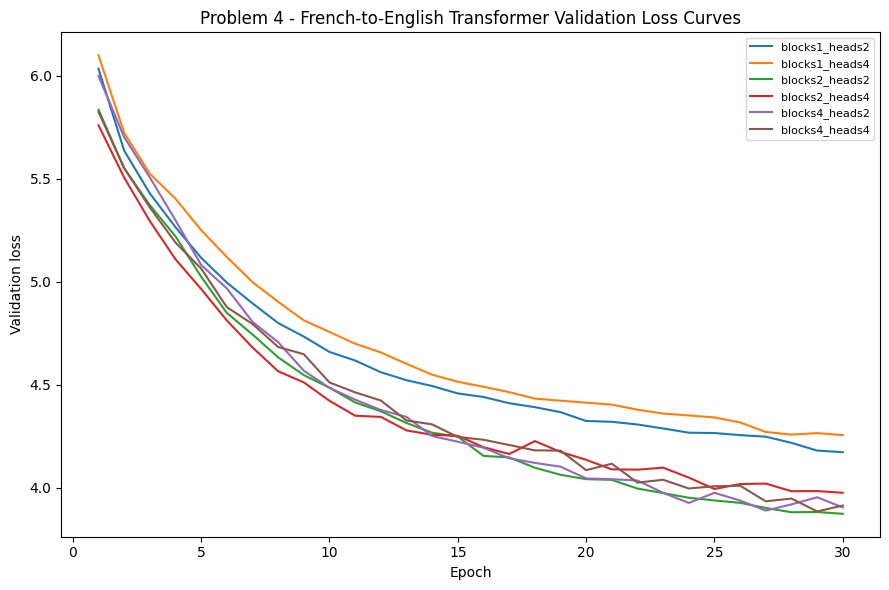

In [5]:
CONFIGS = [(blocks, heads) for blocks in [1, 2, 4] for heads in [2, 4]]
EPOCHS = 30
all_results, all_histories, example_frames = [], {}, []
for blocks, heads in CONFIGS:
    print(f"Running blocks={blocks}, heads={heads}")
    result, history, gen_df = run_translation_config(blocks, heads, epochs=EPOCHS, d_model=128, batch_size=32, lr=3e-4)
    label = f"blocks{blocks}_heads{heads}"
    all_results.append(result)
    all_histories[label] = history
    examples = gen_df.head(10).copy()
    examples.insert(0, "config", label)
    example_frames.append(examples)

results_df = pd.DataFrame(all_results).sort_values(["val_loss", "bleu4"], ascending=[True, False])
examples_df = pd.concat(example_frames, ignore_index=True)
display(results_df)
display(examples_df.head(20))

prefix = "problem3_en_fr" if "fr_en" == "en_fr" else "problem4_fr_en"
results_df.to_csv(OUTPUT_DIR / f"{prefix}_transformer_metrics.csv", index=False)
examples_df.to_csv(OUTPUT_DIR / f"{prefix}_qualitative_examples.csv", index=False)
(OUTPUT_DIR / f"{prefix}_transformer_metrics.json").write_text(json.dumps(all_results, indent=2), encoding="utf-8")

plt.figure(figsize=(9, 6))
for label, history in all_histories.items():
    h = pd.DataFrame(history)
    plt.plot(h["epoch"], h["val_loss"], label=label)
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Problem 4 - French-to-English Transformer Validation Loss Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{prefix}_loss_curves.png", dpi=160)
plt.show()


## Homework 3 RNN Comparison Data
The verified Homework 3 baseline and attention GRU metrics are included for direct comparison against the best Transformer configuration.


In [6]:
hw3_metrics = {"baseline_gru_fr_en": {"train_loss": 1.4040431465421404, "val_loss": 5.185165762901306, "sequence_accuracy": 0.0, "bleu4": 0.09437877146542574}, "attention_gru_fr_en": {"train_loss": 0.7755163354533059, "val_loss": 5.4519041776657104, "sequence_accuracy": 0.0, "bleu4": 0.1146352000939895}}
hw3_df = pd.DataFrame([
    {"model": name, **vals} for name, vals in hw3_metrics.items()
])
display(hw3_df)
hw3_df.to_csv(OUTPUT_DIR / ("problem3_hw3_rnn_comparison.csv" if "fr_en" == "en_fr" else "problem4_hw3_rnn_comparison.csv"), index=False)


,model,train_loss,val_loss,sequence_accuracy,bleu4
0,baseline_gru_fr_en,1.404043,5.185166,0.0,0.094379
1,attention_gru_fr_en,0.775516,5.451904,0.0,0.114635
